# Diabetes Risk Factor Analysis
## Reproducibility Exercise — Starter Notebook

You are a **data scientist at a teaching hospital within a multi-site academic health system**. This preliminary analytical notebook was originally developed for internal exploratory analysis. The **Data Science Director** has asked you to prepare the notebook and supporting files for sharing with the data science team at another clinical site.

The receiving team should be able to obtain the project files, understand the workflow, execute the notebook in its own computational environment, and reproduce the intended results **without contacting you for additional guidance**.

Review the entire notebook, address all embedded **DATA SCIENCE DIRECTOR NOTE** items, identify and resolve additional reproducibility problems, improve the documentation and organization, and verify the final workflow from a clean runtime.

#### Connection to Upcoming Coursework and Final Project

This exercise is an important step in the development of your final project workflow. The reproducibility, documentation, notebook organization, and programming practices you apply in this assignment will build upon your prior Python programming work and serve as a foundation for the Week 3 Automated Analysis Pipeline Exploration assignment.

In Week 3, you will work with a more advanced automated analytical pipeline that incorporates conditional logic, inferential statistical methods, supervised machine learning, model evaluation, and automated analytical decision-making. Many of the practices reinforced in this exercise—including modular programming, reproducible execution, clear Markdown documentation, dependency management, data validation, and logical workflow organization—will be expected in that assignment.

Your work across these assignments will also inform the development of your final project notebook, in which you will adapt and extend a comprehensive example analytical pipeline for your selected dataset.

Complete this exercise thoroughly and with your final project in mind. The goal is not simply to correct the issues identified in the starter notebook, but to develop programming, documentation, and reproducibility practices that you can carry forward into increasingly complex analytical workflows throughout the remainder of the course.

---

## Setup and Environment


this analysis was developed and tested in Google Colab using Python 3. The workflow relies on standard Python data-science libraries for data manipulation, visualization, and statistical analysis.

### Required Python libraries

- `pandas` — data loading and manipulation
- `numpy` — numerical operations
- `matplotlib` — data visualization
- `seaborn` — statistical visualization and correlation heatmap
- `scipy` — inferential statistical testing
- `statsmodels` - statistical modeling and inferential logistic regression

The code cell below imports the required libraries and reports the package versions used in the current environment. Recording these versions helps another analyst identify the computational environment in which the analysis was successfully executed.


In [1]:
# Import libraries required throughout the analysis
import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
import statsmodels
import statsmodels.api as sm

# Report the Python and package versions used for this analysis.
# This information helps another analyst reproduce the computational environment.
print(f"Python version: {sys.version.split()[0]}")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"statsmodels version: {statsmodels.__version__}")

Python version: 3.13.15
pandas version: 2.2.3
numpy version: 2.1.3
matplotlib version: 3.10.0
seaborn version: 0.13.2
scipy version: 1.16.3
statsmodels version: 0.15.0


## Data Source

This analysis uses `Example Dataset_Diabetes.csv`, the example diabetes dataset provided as part of the HSE 751 Reproducibility Exercise. The dataset contains 768 observations and 9 variables representing patient characteristics and a binary diabetes outcome.

The variables included in the dataset are:

- `Pregnancies` — number of pregnancies
- `Glucose` — plasma glucose concentration
- `D_BP` — diastolic blood pressure
- `Skin_Thickness` — triceps skinfold thickness
- `Insulin` — serum insulin
- `BMI` — body mass index
- `Pedigree` — diabetes pedigree function
- `Age` — age in years
- `Outcome` — binary diabetes outcome (`0` = no diabetes, `1` = diabetes)

For this exercise, the CSV file serves as the source dataset for all descriptive, visualization, correlation, and inferential analyses. The original dataset is not modified; all analysis is performed on data loaded into the notebook.

### Loading the dataset in Google Colab

Before running the data-loading cell below:

1. Download `Example Dataset_Diabetes.csv` from this project's GitHub repository.
2. In Google Colab, open the **Files** panel using the folder icon on the left side of the screen.
3. Upload `Example Dataset_Diabetes.csv` to the current Colab session.
4. Run the cell below.

The code checks that the expected file is available before attempting to load it. Files uploaded to Colab session storage are temporary and may need to be uploaded again after restarting or reconnecting the runtime.

In [2]:
# Define the expected dataset location in the Google Colab session.
# Keeping the filename in one variable makes the workflow easier to update
# if the file location changes in the future.
from pathlib import Path

DATA_PATH = Path("/content/Example Dataset_Diabetes.csv")

# Confirm that the required dataset is available before attempting to load it.
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Please upload 'Example Dataset_Diabetes.csv' "
        "to the Google Colab Files panel and rerun this cell."
    )

# Load the diabetes dataset.
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully: {DATA_PATH.name}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Display the first five observations to confirm successful loading.
df.head()

Dataset loaded successfully: Example Dataset_Diabetes.csv
Rows: 768
Columns: 9


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Initial Data Review

### Data Validation
Before beginning the analysis, the dataset is reviewed and validated to confirm that the expected file structure has been loaded. The initial review summarizes the dataset dimensions, missing values, and data types. Additional validation checks confirm that:

- all expected variables are present,
- the dataset contains the expected 9 columns,
- `Outcome` contains only the binary values `0` and `1`,
- no duplicate observations are present, and
- the dataset is not empty.

These checks help detect an incorrect, incomplete, or unexpectedly modified dataset before subsequent analyses are performed.

In [3]:
# Review basic dataset characteristics before formal validation.
print("Shape:", df.shape)

print("\nMissing values by variable:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

Shape: (768, 9)

Missing values by variable:
Pregnancies       0
Glucose           0
D_BP              0
Skin_Thickness    0
Insulin           0
BMI               0
Pedigree          0
Age               0
Outcome           0
dtype: int64

Data types:
Pregnancies         int64
Glucose             int64
D_BP                int64
Skin_Thickness      int64
Insulin             int64
BMI               float64
Pedigree          float64
Age                 int64
Outcome             int64
dtype: object


In [4]:
# Define the variables expected in the diabetes dataset.
expected_columns = [
    "Pregnancies",
    "Glucose",
    "D_BP",
    "Skin_Thickness",
    "Insulin",
    "BMI",
    "Pedigree",
    "Age",
    "Outcome"
]

# Check 1: Confirm that the dataset is not empty.
assert not df.empty, "Validation failed: the dataset contains no observations."

# Check 2: Confirm that all expected columns are present.
missing_columns = [col for col in expected_columns if col not in df.columns]
assert not missing_columns, (
    f"Validation failed: expected columns are missing: {missing_columns}"
)

# Check 3: Confirm that no unexpected columns are present.
unexpected_columns = [col for col in df.columns if col not in expected_columns]
assert not unexpected_columns, (
    f"Validation failed: unexpected columns were found: {unexpected_columns}"
)

# Check 4: Confirm the expected number of columns.
assert df.shape[1] == 9, (
    f"Validation failed: expected 9 columns but found {df.shape[1]}."
)

# Check 5: Confirm that Outcome is a binary variable coded as 0 and 1.
outcome_values = set(df["Outcome"].dropna().unique())
assert outcome_values == {0, 1}, (
    f"Validation failed: Outcome should contain only 0 and 1, "
    f"but found {sorted(outcome_values)}."
)

# Check 6: Identify duplicate observations.
duplicate_count = df.duplicated().sum()

# Report successful validation.
print("Dataset validation passed.")
print(f"Observations: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")
print(f"Duplicate rows: {duplicate_count}")
print(f"Outcome values: {sorted(int(x) for x in outcome_values)}")

Dataset validation passed.
Observations: 768
Variables: 9
Duplicate rows: 0
Outcome values: [0, 1]


### Validation Result

The dataset passed all structural validation checks. It contains 768 observations and the nine expected variables, with no duplicate rows identified. The `Outcome` variable contains the expected binary values of `0` (no diabetes) and `1` (diabetes). The initial review also identified no conventionally encoded missing (`NaN`) values.

These checks confirm that the expected dataset structure has been loaded successfully and is appropriate to proceed with the planned analyses. However, structural validation does not guarantee that every recorded value is clinically plausible. For example, physiologically implausible zero values may be present in some clinical variables even though they are not encoded as missing values. This issue should be considered when interpreting the results and is noted as a limitation of the analysis.

## Data Preparation

Following validation, the dataset was retained in its original analytical structure. No observations were removed, and no missing-value imputation, scaling, or feature transformation was performed for this exercise.

The `Outcome` variable is retained as a binary variable coded as `0` (no diabetes) and `1` (diabetes). The remaining eight variables are used as patient characteristics in the descriptive, visualization, correlation, and inferential analyses below.

Although physiologically implausible zero values were identified in some clinical variables, these values were retained rather than recoded because the purpose of this exercise is to reproduce and document the provided analytical workflow. Their potential influence on the results is acknowledged as a limitation.

## Descriptive Statistics

In [5]:
df.describe()

# Summarize selected patient characteristics that are especially
# relevant to the diabetes risk factor analysis.
summary_variables = ["Glucose", "BMI", "Age"]

summary_stats = df[summary_variables].agg(["mean", "std"]).T
summary_stats.columns = ["Mean", "Standard Deviation"]

# Round values for easier interpretation.
summary_stats = summary_stats.round(2)

summary_stats

,Mean,Standard Deviation
Glucose,120.89,31.97
BMI,31.99,7.88
Age,33.24,11.76


### Mean and Standard Deviation

The mean and standard deviation are used here to summarize the center and variability of continuous patient characteristics in the diabetes dataset. For a variable \(x\), the sample mean is calculated as:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

where \(\bar{x}\) is the sample mean, \(x_i\) is the value for patient \(i\), and \(n\) is the number of observations.

The sample standard deviation is calculated as:

$$
s = \sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}
$$

where \(s\) represents the sample standard deviation and describes how much individual patient values vary around the sample mean.

In this dataset, the mean glucose value is approximately **120.89** with a standard deviation of **31.97**, indicating substantial variability in glucose measurements across the 768 observations. Mean BMI is approximately **31.99 kg/m²** with a standard deviation of **7.88 kg/m²**, while mean age is approximately **33.24 years** with a standard deviation of **11.76 years**.

These descriptive statistics provide context for the patient population before examining relationships with the diabetes outcome. In particular, the variability observed in glucose, BMI, and age suggests that patients differ meaningfully across characteristics that may be relevant to diabetes status. Mean and standard deviation summarize these distributions but do not by themselves establish whether a characteristic is associated with the diabetes outcome; those relationships are examined in subsequent visualizations and inferential analyses.

***** DATA SCIENCE DIRECTOR NOTE *****

The mathematical notation in this section is not rendering properly. Please correct the Markdown/LaTeX formatting so that the equations and mathematical symbols display appropriately.

The explanation is also too generic. Please revise the narrative so that it is specific to this dataset and helps the reader understand how the mean and standard deviation are being used to summarize relevant patient characteristics. Do not simply provide definitions of the statistics -- connect the explanation to the variables and results in this analysis.

## Visualizations
### Bivariate Visualizations

The following visualizations extend the univariate summaries by examining relationships between patient characteristics and diabetes status. A boxplot is used to compare glucose distributions between outcome groups, while a scatterplot examines the relationship between BMI and glucose and shows how diabetes outcomes are distributed across these two characteristics.

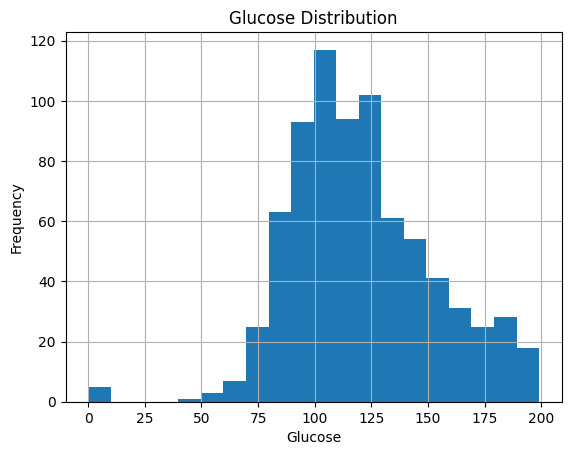

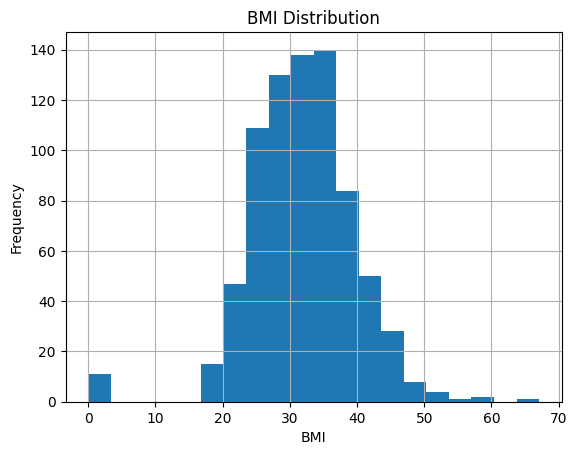

In [6]:
df["Glucose"].hist(bins=20)
plt.title("Glucose Distribution")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

df["BMI"].hist(bins=20)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

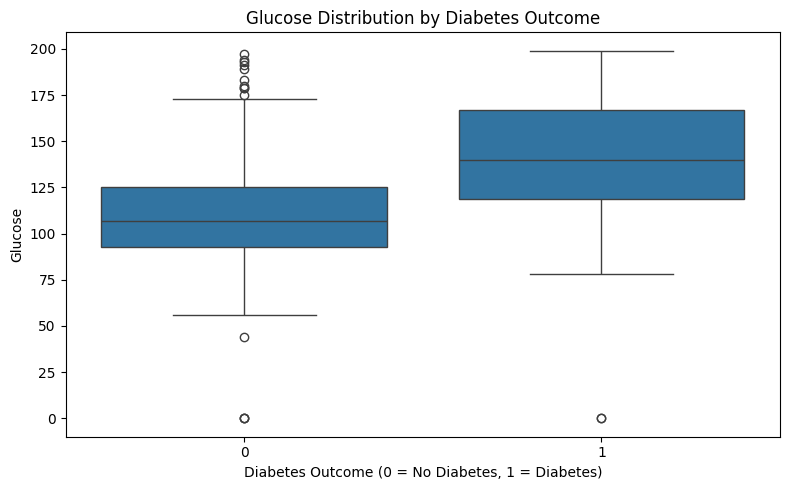

In [7]:
# Compare the distribution of glucose values between patients
# without diabetes (Outcome = 0) and with diabetes (Outcome = 1).

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Outcome",
    y="Glucose"
)

plt.title("Glucose Distribution by Diabetes Outcome")
plt.xlabel("Diabetes Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Glucose")
plt.tight_layout()
plt.show()

#### Interpretation

Glucose values were visibly higher among patients with diabetes (`Outcome = 1`) than among patients without diabetes (`Outcome = 0`). The median glucose value was approximately 140 in the diabetes group compared with approximately 107 in the non-diabetes group, and the interquartile range was also shifted toward higher glucose values among patients with diabetes. Although the distributions overlap, the clear upward shift in glucose among patients with diabetes suggests an association between glucose level and diabetes status in this dataset.

Several unusually low values are also visible, including glucose values of zero. Because a glucose measurement of zero is not physiologically plausible, these observations may represent missing or invalid measurements that were encoded as zero rather than `NaN`. This data-quality limitation should be considered when interpreting the analysis. The difference in glucose between outcome groups is formally evaluated in the inferential analysis below.

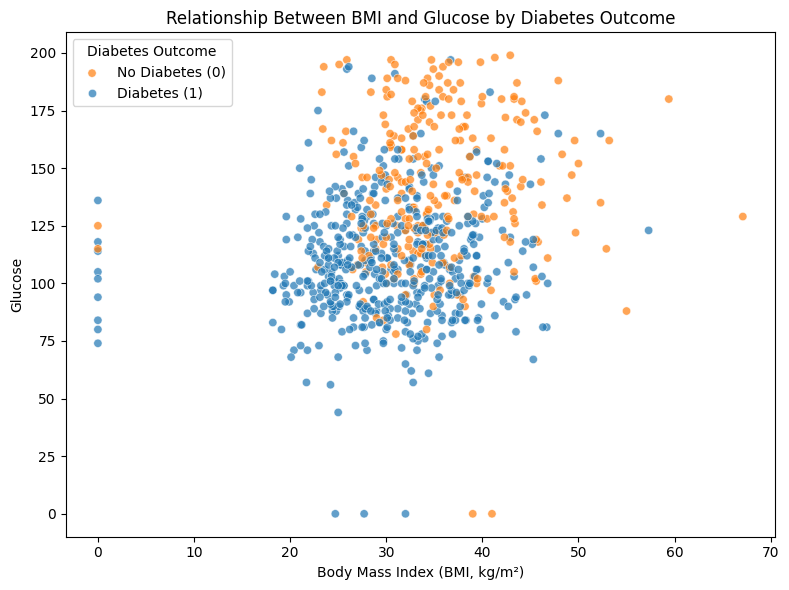

In [8]:
# Examine the relationship between BMI and glucose while distinguishing
# observations according to diabetes outcome.

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="BMI",
    y="Glucose",
    hue="Outcome",
    alpha=0.7
)

plt.title("Relationship Between BMI and Glucose by Diabetes Outcome")
plt.xlabel("Body Mass Index (BMI, kg/m²)")
plt.ylabel("Glucose")
plt.legend(
    title="Diabetes Outcome",
    labels=["No Diabetes (0)", "Diabetes (1)"]
)
plt.tight_layout()
plt.show()

#### Interpretation

The scatterplot shows considerable overlap in BMI values between patients with and without diabetes, indicating that BMI alone does not clearly distinguish the two outcome groups. In contrast, diabetes-positive observations (`Outcome = 1`) are more concentrated at higher glucose values, while patients without diabetes (`Outcome = 0`) are more densely represented at lower glucose values.

Across the range of BMI values, glucose remains highly variable, and the plot does not show a strong linear relationship between BMI and glucose. Instead, glucose appears to provide clearer visual separation between diabetes outcome groups than BMI in this dataset. Several observations with BMI or glucose values of zero are also visible and may represent invalid or missing measurements encoded as zero. These patterns are exploratory associations and should not be interpreted as evidence that either BMI or glucose causes diabetes.

### Correlation Analysis

A correlation matrix was used to examine pairwise associations among the numerical variables in the diabetes dataset. **Spearman's rank correlation** was selected because several variables in the dataset are skewed, discrete, contain potential outliers, or include physiologically implausible zero values. Unlike Pearson's correlation, Spearman's correlation is based on ranked values and does not require a linear relationship or normally distributed variables.

Spearman's correlation coefficient, \(\rho\), ranges from -1 to 1. Positive values indicate that two variables tend to increase together, negative values indicate that one tends to decrease as the other increases, and values closer to zero indicate weaker monotonic relationships.

`Outcome` is included as a binary variable (`0` = no diabetes, `1` = diabetes) to provide a descriptive view of how patient characteristics are associated with diabetes status. Correlations involving `Outcome` should be interpreted as descriptive associations rather than correlations between two continuous measurements.

In [9]:
# Select the numerical variables used in the correlation analysis.
correlation_variables = [
    "Pregnancies",
    "Glucose",
    "D_BP",
    "Skin_Thickness",
    "Insulin",
    "BMI",
    "Pedigree",
    "Age",
    "Outcome"
]

# Calculate the Spearman rank-correlation matrix.
spearman_corr = df[correlation_variables].corr(method="spearman")

# Display the correlation coefficients as a table.
spearman_corr.round(2)

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
Pregnancies,1.00,0.13,0.19,-0.09,-0.13,0.00,-0.04,0.61,0.20
Glucose,0.13,1.00,0.24,0.06,0.21,0.23,0.09,0.29,0.48
D_BP,0.19,0.24,1.00,0.13,-0.01,0.29,0.03,0.35,0.14
Skin_Thickness,-0.09,0.06,0.13,1.00,0.54,0.44,0.18,-0.07,0.09
Insulin,-0.13,0.21,-0.01,0.54,1.00,0.19,0.22,-0.11,0.07
BMI,0.00,0.23,0.29,0.44,0.19,1.00,0.14,0.13,0.31
Pedigree,-0.04,0.09,0.03,0.18,0.22,0.14,1.00,0.04,0.18
Age,0.61,0.29,0.35,-0.07,-0.11,0.13,0.04,1.00,0.31
Outcome,0.20,0.48,0.14,0.09,0.07,0.31,0.18,0.31,1.00


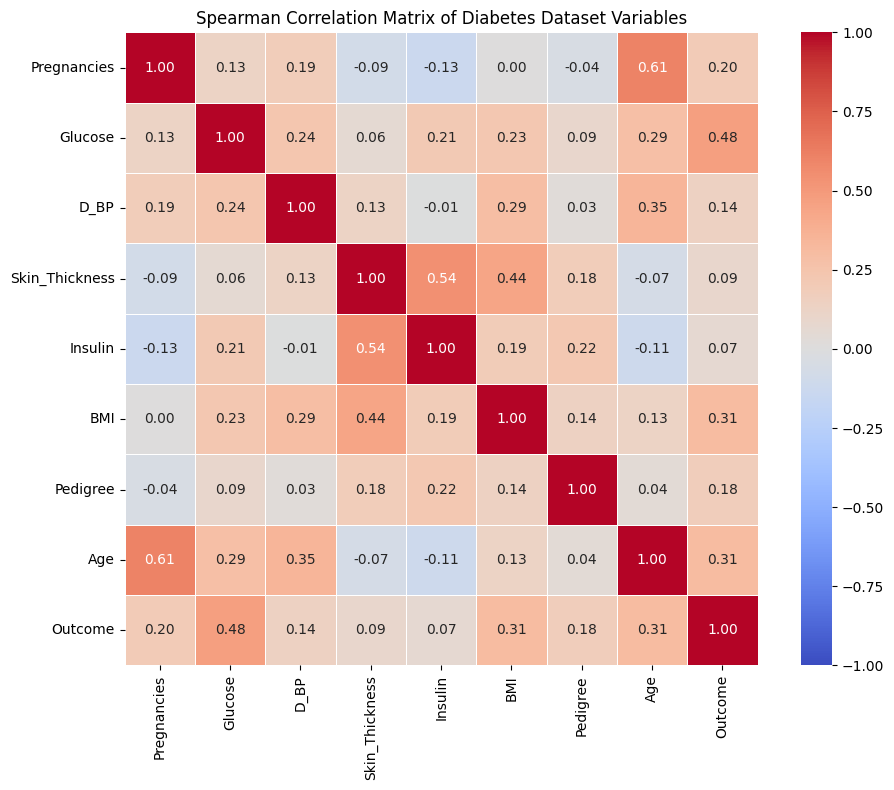

In [10]:
# Visualize the Spearman correlation matrix as a heatmap.
plt.figure(figsize=(10, 8))

sns.heatmap(
    spearman_corr,
    annot=True,          # Display correlation coefficients in each cell
    fmt=".2f",           # Round displayed values to two decimal places
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix of Diabetes Dataset Variables")
plt.tight_layout()
plt.show()

#### Interpretation

The Spearman correlation matrix identified several notable positive associations among variables in the diabetes dataset. The strongest relationship between two patient characteristics was between **age and number of pregnancies** (\(\rho = 0.61\)), indicating that older patients tended to report more pregnancies. **Skin thickness and insulin** were also moderately positively correlated (\(\rho = 0.54\)), while **skin thickness and BMI** showed a moderate positive association (\(\rho = 0.44\)).

Among the patient characteristics examined in relation to diabetes status, **glucose had the strongest positive association with `Outcome`** (\(\rho = 0.48\)). This indicates that higher glucose values tended to occur among patients with diabetes (`Outcome = 1`), which is consistent with the pattern observed in the earlier boxplot. **BMI and age** each showed weaker positive associations with diabetes status (\(\rho = 0.31\)). Pregnancies (\(\rho = 0.20\)) and pedigree (\(\rho = 0.18\)) had smaller positive associations with the outcome, while blood pressure, skin thickness, and insulin showed relatively weak associations with diabetes status in this dataset.

Overall, no pairwise correlation involving `Outcome` was extremely strong, suggesting that diabetes status is not characterized by a single patient characteristic alone in these data. These coefficients describe pairwise monotonic associations and should not be interpreted as evidence that any of these variables causes diabetes. In addition, potential data-quality issues, including physiologically implausible zero values in some clinical variables, may influence the observed correlations.

## Inferential Analysis

The following analysis compares glucose values between the two outcome groups.

In [11]:
from scipy.stats import ttest_ind

group_0 = df.loc[df["Outcome"] == 0, "Glucose"]
group_1 = df.loc[df["Outcome"] == 1, "Glucose"]

t_stat, p_value = ttest_ind(group_0, group_1)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -14.600060005973894
p-value: 8.935431645289912e-43


### Additional Inferential Analysis: Logistic Regression

#### Purpose

A univariable logistic regression was conducted to evaluate whether **BMI is associated with diabetes status** in this dataset. Logistic regression is appropriate because the dependent variable, `Outcome`, is binary (`0` = no diabetes, `1` = diabetes), while BMI is a continuous patient characteristic.

The model can be expressed as:

$$
\log\left(\frac{p_i}{1-p_i}\right)
=
\beta_0 + \beta_1(\text{BMI}_i)
$$

where:

- \(p_i = P(Y_i = 1)\) is the probability that patient \(i\) has diabetes,
- \(\frac{p_i}{1-p_i}\) represents the odds of diabetes,
- \(\beta_0\) is the intercept, and
- \(\beta_1\) represents the change in the log-odds of diabetes associated with a one-unit increase in BMI.

Exponentiating the BMI coefficient produces an **odds ratio**:

$$
OR = e^{\beta_1}
$$

An odds ratio greater than 1 indicates higher odds of diabetes as BMI increases, while an odds ratio less than 1 indicates lower odds. Statistical significance is evaluated using the estimated coefficient and its p-value, with \(p < 0.05\) used as the conventional significance threshold for this analysis.

In [12]:
# Fit a univariable logistic regression model examining the association
# between BMI and the binary diabetes outcome.

# Predictor variable: BMI
X = df[["BMI"]]

# Add an intercept term to the regression model.
X = sm.add_constant(X)

# Binary outcome: 0 = no diabetes, 1 = diabetes
y = df["Outcome"]

# Fit the logistic regression model.
logit_model = sm.Logit(y, X).fit(disp=False)

# Extract the BMI coefficient and inferential statistics.
bmi_beta = logit_model.params["BMI"]
bmi_p_value = logit_model.pvalues["BMI"]

# Convert the log-odds coefficient to an odds ratio.
bmi_or = np.exp(bmi_beta)

# Calculate the 95% confidence interval for the odds ratio.
bmi_ci = logit_model.conf_int().loc["BMI"]
bmi_ci_lower = np.exp(bmi_ci[0])
bmi_ci_upper = np.exp(bmi_ci[1])

# Display the results in an interpretable format.
print(f"BMI coefficient (β): {bmi_beta:.4f}")
print(f"Odds ratio (OR): {bmi_or:.3f}")
print(f"95% CI for OR: ({bmi_ci_lower:.3f}, {bmi_ci_upper:.3f})")
print(f"P-value: {bmi_p_value:.4g}")

BMI coefficient (β): 0.0935
Odds ratio (OR): 1.098
95% CI for OR: (1.072, 1.124)
P-value: 8.45e-15


#### Logistic Regression Results and Interpretation

BMI was significantly associated with diabetes status in the univariable logistic regression model. The estimated BMI coefficient was \(\beta_1 = 0.0935\), corresponding to an odds ratio of **1.098** (95% CI: **1.072–1.124**, \(p < 0.001\)).

This odds ratio indicates that, in this dataset, each **1 kg/m² increase in BMI was associated with approximately 9.8% higher odds of diabetes**:

$$
(1.098 - 1)\times100 = 9.8\%
$$

The 95% confidence interval does not include 1, and the p-value is well below 0.05, providing evidence of a statistically significant positive association between BMI and diabetes status. This finding is also consistent with the earlier Spearman correlation analysis, in which BMI showed a positive association with `Outcome` (\(\rho = 0.31\)).

This model evaluates the **unadjusted association** between BMI and diabetes status. It does not account for other patient characteristics such as glucose or age, and the observational nature of the dataset does not support a causal interpretation. Additionally, potentially invalid BMI values encoded as zero may influence the estimated association.

## Data, Statistics, and the Machine Learning Workflow

### Formalizing the Diabetes Dataset

The diabetes dataset can be represented as a supervised binary classification problem. Each observation corresponds to one patient record and contains eight predictor variables together with a binary diabetes outcome.

The complete dataset can be represented as:

$$
\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{n},
\qquad
\mathbf{x}_i \in \mathbb{R}^{8},
\qquad
y_i \in \{0,1\}
$$

where:

- \(\mathcal{D}\) represents the complete diabetes dataset,
- \(n = 768\) is the number of observations,
- \(i\) indexes an individual observation,
- \(\mathbf{x}_i\) is the vector of predictor values for observation \(i\),
- \(p = 8\) is the number of predictor variables, and
- \(y_i\) is the binary diabetes outcome for observation \(i\).

For this dataset, the predictor vector is:

$$
\mathbf{x}_i =
\begin{bmatrix}
\text{Pregnancies}_i \\
\text{Glucose}_i \\
\text{D\_BP}_i \\
\text{Skin\_Thickness}_i \\
\text{Insulin}_i \\
\text{BMI}_i \\
\text{Pedigree}_i \\
\text{Age}_i
\end{bmatrix}
$$

and the target variable is:

$$
y_i = \text{Outcome}_i,
\qquad
y_i \in \{0,1\}
$$

where:

- \(y_i = 0\) represents no diabetes, and
- \(y_i = 1\) represents diabetes.

Thus, each observation is represented by eight patient characteristics that could be used to estimate diabetes status.

### Connection to Supervised Machine Learning

In a supervised machine-learning framework, the goal would be to use the eight predictor variables to learn an estimated function:

$$
\hat{f}: \mathbb{R}^{8} \rightarrow \{0,1\}
$$

such that:

$$
\hat{y}_i = \hat{f}(\mathbf{x}_i)
$$

where \(\hat{y}_i\) is the predicted diabetes class for observation \(i\).

The objective of a predictive model would be to learn patterns relating `Pregnancies`, `Glucose`, `D_BP`, `Skin_Thickness`, `Insulin`, `BMI`, `Pedigree`, and `Age` to the binary `Outcome` and then evaluate how well those learned relationships generalize to observations not used to fit the model.

The analyses in this notebook are primarily **descriptive and inferential rather than a complete machine-learning pipeline**. The visualizations, correlation analysis, t-test, and logistic regression examine relationships among these variables and the diabetes outcome, but the notebook does not train and evaluate a multivariable predictive classifier. This mathematical representation establishes how the same dataset could be structured for a subsequent supervised machine-learning workflow.

## Reproducibility Check

Some analytical operations use random sampling and can produce different results each time the notebook is executed. To ensure reproducibility, a fixed random seed is used for all stochastic operations in this workflow.

Using the same seed causes the pseudorandom sampling process to generate the same result each time the notebook is executed from the same data and computational environment. Here, `RANDOM_SEED = 42` is used consistently for both the random participant sample and the bootstrap sample.

In [13]:
# Set a fixed random seed for reproducible stochastic operations.
RANDOM_SEED = 42

print(f"Random seed used for reproducibility: {RANDOM_SEED}")

Random seed used for reproducibility: 42


In [14]:
# Display a reproducible sample of eight observations.
# random_state ensures the same rows are selected each time.
participant_sample = df.sample(
    n=8,
    random_state=RANDOM_SEED
)

participant_sample

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
668,6,98,58,33,190,34.0,0.430,43,0
324,2,112,75,32,0,35.7,0.148,21,0
624,2,108,64,0,0,30.8,0.158,21,0
690,8,107,80,0,0,24.6,0.856,34,0
473,7,136,90,0,0,29.9,0.210,50,0
204,6,103,72,32,190,37.7,0.324,55,0
97,1,71,48,18,76,20.4,0.323,22,0
336,0,117,0,0,0,33.8,0.932,44,0


In [15]:
# Generate a reproducible bootstrap sample of BMI values.
# Sampling with replacement creates a sample equal in size to the
# original dataset, while random_state ensures identical results
# across repeated executions.

bootstrap_sample = df["BMI"].sample(
    n=len(df),
    replace=True,
    random_state=RANDOM_SEED
)

bootstrap_mean_bmi = bootstrap_sample.mean()

print(f"Bootstrap mean BMI: {bootstrap_mean_bmi:.4f}")

Bootstrap mean BMI: 31.9307


## Results and Conclusions

### Major Findings

This analysis examined relationships between patient characteristics and diabetes status among 768 observations in the provided diabetes dataset.

Descriptive analysis showed substantial variation in several patient characteristics. Mean glucose was approximately **120.89** (SD **31.97**), mean BMI was **31.99 kg/m²** (SD **7.88 kg/m²**), and mean age was **33.24 years** (SD **11.76 years**).

The bivariate analyses demonstrated a clear difference in glucose distributions by diabetes status. Patients with diabetes (`Outcome = 1`) generally had higher glucose values than patients without diabetes (`Outcome = 0`). The BMI-versus-glucose scatterplot showed considerable overlap in BMI between outcome groups, while diabetes-positive observations were more concentrated at higher glucose values.

Spearman correlation analysis similarly identified **glucose as the patient characteristic most strongly associated with diabetes status** (\(\rho = 0.48\)). BMI and age each showed weaker positive associations with `Outcome` (\(\rho = 0.31\)). Among the predictor variables themselves, notable relationships included age with pregnancies (\(\rho = 0.61\)), skin thickness with insulin (\(\rho = 0.54\)), and skin thickness with BMI (\(\rho = 0.44\)).

Inferential analyses provided additional evidence of associations with diabetes status. Glucose values differed significantly between the two outcome groups in the independent-samples t-test (\(t = -14.60\), \(p < 0.001\)). In the univariable logistic regression, higher BMI was significantly associated with greater odds of diabetes (\(OR = 1.098\), 95% CI: 1.072–1.124, \(p < 0.001\)). This corresponds to approximately **9.8% higher odds of diabetes for each 1 kg/m² increase in BMI** in this unadjusted analysis.

### Limitations

Several limitations should be considered when interpreting these findings. Although the dataset contains no conventionally encoded missing (`NaN`) values, physiologically implausible zero values are present in some clinical variables, including glucose and BMI. These values may represent missing or invalid measurements and were retained in this exercise rather than recoded or imputed. Their presence may influence descriptive statistics, correlations, visualizations, and inferential estimates.

The analyses are primarily descriptive and inferential and do not establish causal relationships. The logistic regression evaluates the unadjusted association between BMI and diabetes status and does not account for potential confounding by glucose, age, or other patient characteristics. Additionally, this notebook does not train or evaluate a multivariable predictive model, so the results should not be interpreted as measures of predictive performance.

### Conclusion

In this dataset, diabetes status was associated with multiple patient characteristics, with glucose demonstrating the strongest pairwise association with the outcome and BMI showing a statistically significant positive association with the odds of diabetes. The workflow demonstrates a reproducible approach to data validation, descriptive analysis, visualization, correlation analysis, and inferential statistical testing while documenting important data-quality and analytical limitations.